# Datathon Passos Mágicos — Análise Exploratória e Storytelling

## 03 — Análise dos indicadores educacionais

Este notebook utiliza a base longitudinal tratada no `02_tratamento.ipynb` para responder às perguntas de negócio do Datathon.

O foco aqui é **análise e interpretação**. O modelo preditivo será desenvolvido separadamente no `04_modelo_ml.ipynb`.

### Perguntas analisadas

1. Adequação ao nível (IAN) e defasagem;
2. Desempenho acadêmico (IDA);
3. Relação entre engajamento (IEG), desempenho (IDA) e ponto de virada (IPV);
4. Coerência da autoavaliação (IAA);
5. Aspectos psicossociais (IPS) e quedas futuras;
6. Aspectos psicopedagógicos (IPP) e defasagem;
7. Indicadores associados ao ponto de virada (IPV);
8. Combinações de indicadores associadas a maior INDE;
9. Preparação da análise de risco para Machine Learning;
10. Evidências de efetividade do programa;
11. Insights adicionais.

> **Importante:** associações e correlações não representam causalidade. Mudanças entre anos também podem refletir alterações de composição da base, instrumentos de avaliação e disponibilidade de dados.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 1. Carregamento das bases tratadas

A análise utiliza:

- `base_tratada.csv`: base longitudinal com um registro por aluno/ano;
- `base_modelo_temporal.csv`: recorte 2023 → 2024 criado para estudar a previsão de nova defasagem.

In [2]:
def localizar_arquivo(nome):
    candidatos = [
        Path("../data/processed") / nome,
        Path("data/processed") / nome,
        Path("/mnt/data") / nome,
    ]
    for caminho in candidatos:
        if caminho.exists():
            return caminho
    raise FileNotFoundError(f"Arquivo não encontrado: {nome}")

BASE_PATH = localizar_arquivo("base_tratada.csv")
MODELO_PATH = localizar_arquivo("base_modelo_temporal.csv")

df = pd.read_csv(BASE_PATH)
df_modelo = pd.read_csv(MODELO_PATH)

print(f"Base tratada: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Base temporal: {df_modelo.shape[0]:,} linhas x {df_modelo.shape[1]} colunas")
print(f"Períodos disponíveis: {sorted(df['ano'].unique())}")

Base tratada: 3,030 linhas x 42 colunas
Base temporal: 765 linhas x 23 colunas
Períodos disponíveis: [np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. Panorama geral

Antes de responder cada pergunta, será construído um resumo anual dos principais indicadores e da taxa de defasagem.

In [3]:
indicadores = ["inde", "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]

resumo_anual = (
    df.groupby("ano")
      .agg(
          alunos=("ra", "size"),
          inde=("inde", "mean"),
          ian=("ian", "mean"),
          ida=("ida", "mean"),
          ieg=("ieg", "mean"),
          iaa=("iaa", "mean"),
          ips=("ips", "mean"),
          ipp=("ipp", "mean"),
          ipv=("ipv", "mean"),
          taxa_defasagem=("em_defasagem", "mean"),
      )
      .reset_index()
)

resumo_anual["taxa_defasagem"] *= 100
display(resumo_anual.round(2))

,ano,alunos,inde,ian,ida,ieg,iaa,ips,ipp,ipv,taxa_defasagem
0,2022,860,7.04,6.42,6.09,7.89,8.27,6.90,NaN,7.25,69.88
1,2023,1014,7.34,7.24,6.66,8.70,6.90,5.12,7.56,8.03,54.44
2,2024,1156,7.40,7.68,6.35,7.37,8.54,6.83,7.55,7.35,46.19


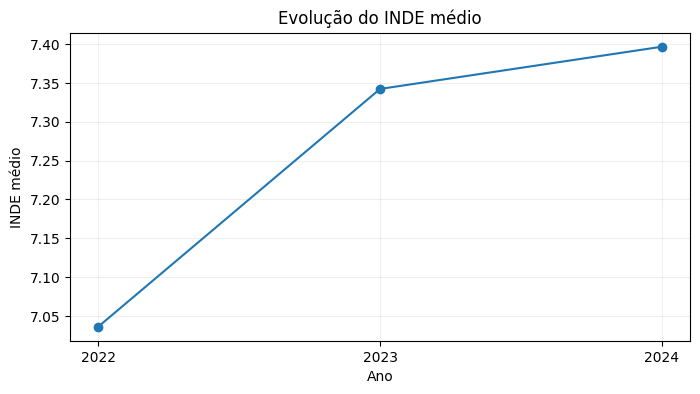

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(resumo_anual["ano"], resumo_anual["inde"], marker="o")
plt.xticks(resumo_anual["ano"])
plt.title("Evolução do INDE médio")
plt.xlabel("Ano")
plt.ylabel("INDE médio")
plt.grid(alpha=0.2)
plt.show()

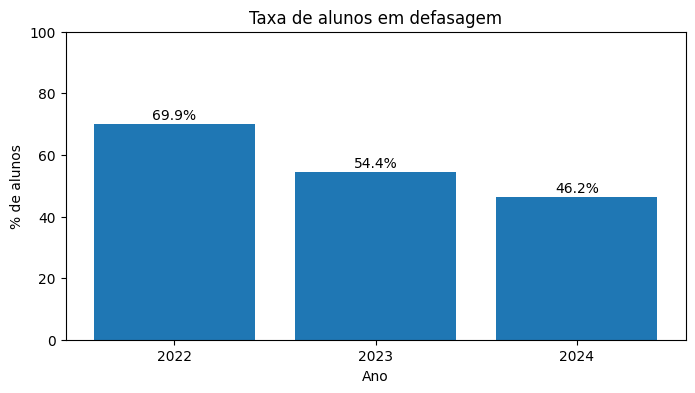

In [5]:
plt.figure(figsize=(8, 4))
plt.bar(resumo_anual["ano"].astype(str), resumo_anual["taxa_defasagem"])
plt.title("Taxa de alunos em defasagem")
plt.xlabel("Ano")
plt.ylabel("% de alunos")
plt.ylim(0, 100)

for i, valor in enumerate(resumo_anual["taxa_defasagem"]):
    plt.text(i, valor + 1.5, f"{valor:.1f}%", ha="center")

plt.show()

### Leitura inicial

A base mostra dois sinais agregados favoráveis:

- o **INDE médio** passou de **7,04 em 2022** para **7,34 em 2023** e **7,40 em 2024**;
- a proporção de alunos em defasagem caiu de **69,9%** para **54,4%** e depois para **46,2%**.

No entanto, esses números agregados não são suficientes para afirmar impacto causal do programa. As próximas análises verificam se a melhora aparece também nos demais indicadores e entre os mesmos alunos ao longo do tempo.

# Pergunta 1 — Adequação do nível (IAN)

> Qual é o perfil geral de defasagem dos alunos e como ele evolui?

Na base tratada, o IAN possui três valores principais: `2.5`, `5.0` e `10.0`.

A relação observada nos próprios dados é:

- `IAN = 10`: aluno adequado ou adiantado;
- `IAN = 5`: defasagem de 1 ou 2 fases;
- `IAN = 2.5`: defasagem de 3 ou mais fases.

Essa classificação é **operacional e inferida pela consistência entre IAN e a variável de defasagem da própria base**.

In [6]:
ian_defasagem = pd.crosstab(df["defasagem"], df["ian"])
display(ian_defasagem)

ian,2.5,5.0,10.0
defasagem,,,
-5.0,1,0,0
-4.0,5,0,0
-3.0,39,0,0
-2.0,0,383,0
-1.0,0,1259,0
0.0,0,0,1154
1.0,0,0,165
2.0,0,0,24


In [7]:
perfil_ian = (
    df.groupby(["ano", "ian"])
      .size()
      .rename("alunos")
      .reset_index()
)

perfil_ian["percentual"] = (
    perfil_ian["alunos"]
    / perfil_ian.groupby("ano")["alunos"].transform("sum")
    * 100
)

display(perfil_ian.round(2))

,ano,ian,alunos,percentual
0,2022,2.5,28,3.26
1,2022,5.0,573,66.63
2,2022,10.0,259,30.12
3,2023,2.5,14,1.38
4,2023,5.0,538,53.06
5,2023,10.0,462,45.56
6,2024,2.5,3,0.26
7,2024,5.0,531,45.93
8,2024,10.0,622,53.81


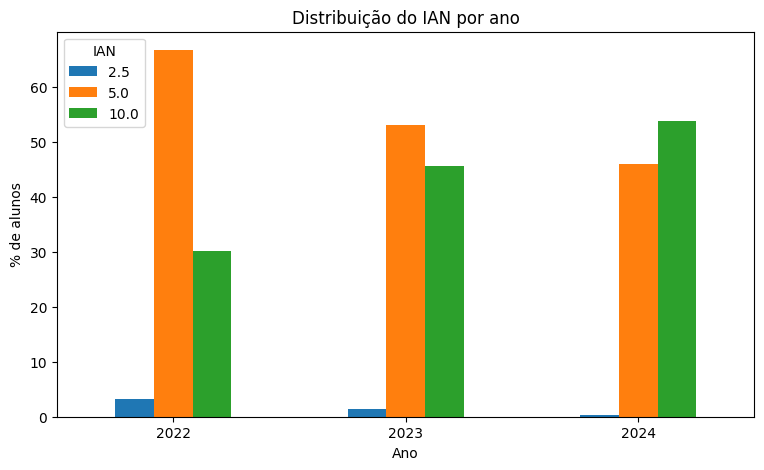

In [8]:
pivot_ian = perfil_ian.pivot(index="ano", columns="ian", values="percentual").fillna(0)

pivot_ian.plot(kind="bar", figsize=(9, 5))
plt.title("Distribuição do IAN por ano")
plt.xlabel("Ano")
plt.ylabel("% de alunos")
plt.xticks(rotation=0)
plt.legend(title="IAN")
plt.show()

### Insight — IAN e defasagem

A melhora na adequação ao nível é clara:

- alunos com `IAN = 2.5`, situação de maior defasagem observada, caíram de **28 em 2022** para **14 em 2023** e apenas **3 em 2024**;
- alunos com `IAN = 5` passaram de **573** para **538** e **531**;
- alunos com `IAN = 10` cresceram de **259** para **462** e **622**.

Portanto, o principal avanço está no crescimento do grupo adequado/adiantado e na forte redução das defasagens mais profundas.

# Pergunta 2 — Desempenho acadêmico (IDA)

> O desempenho acadêmico médio está melhorando, estagnado ou caindo ao longo das fases e anos?

In [9]:
ida_ano = df.groupby("ano")["ida"].agg(["count", "mean", "median", "std"]).round(2)
display(ida_ano)

,count,mean,median,std
ano,,,,
2022,860,6.09,6.30,2.05
2023,937,6.66,6.80,1.60
2024,1055,6.35,6.75,2.13


In [10]:
fase_ordem = ["ALFA"] + [f"FASE {i}" for i in range(1, 10)]

ida_fase = (
    df.groupby(["ano", "fase"])["ida"]
      .mean()
      .unstack("ano")
      .reindex(fase_ordem)
)

display(ida_fase.round(2))

ano,2022,2023,2024
fase,,,
ALFA,7.14,7.42,7.32
FASE 1,6.46,6.81,6.79
FASE 2,5.41,6.74,6.25
FASE 3,5.14,5.75,5.35
FASE 4,6.05,6.00,5.88
FASE 5,5.87,5.90,6.45
FASE 6,6.69,6.81,7.23
FASE 7,5.25,7.81,5.81
FASE 8,NaN,NaN,8.00


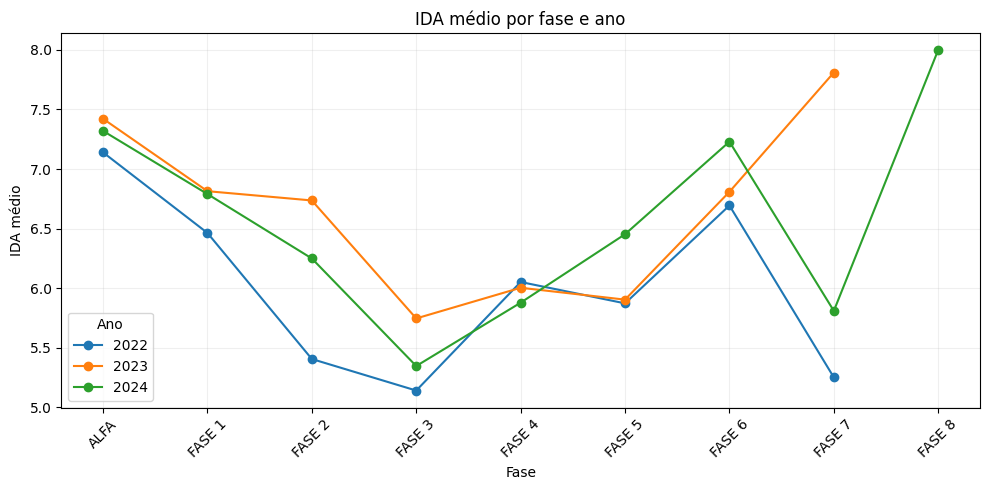

In [11]:
plt.figure(figsize=(10, 5))

for ano in ida_fase.columns:
    plt.plot(ida_fase.index, ida_fase[ano], marker="o", label=str(ano))

plt.title("IDA médio por fase e ano")
plt.xlabel("Fase")
plt.ylabel("IDA médio")
plt.xticks(rotation=45)
plt.legend(title="Ano")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Insight — desempenho acadêmico

O IDA médio evoluiu de **6,09 em 2022** para **6,66 em 2023**, mas recuou para **6,35 em 2024**.

Portanto, a série agregada **não apresenta melhora contínua**: houve avanço em 2023 e perda parcial em 2024.

Entre os mesmos alunos presentes em 2023 e 2024, a queda também aparece: a variação média do IDA foi aproximadamente **-0,48 ponto**, indicando que o recuo de 2024 não é explicado apenas pela entrada de novos alunos.

## Análise longitudinal dos mesmos alunos

A comparação abaixo acompanha apenas alunos presentes nos dois períodos, reduzindo o efeito de mudança de composição da base.

In [12]:
def comparar_periodos(df, ano_inicial, ano_final, colunas):
    inicial = df[df["ano"] == ano_inicial].set_index("ra")[colunas]
    final = df[df["ano"] == ano_final].set_index("ra")[colunas]

    pares = inicial.join(
        final,
        how="inner",
        lsuffix=f"_{ano_inicial}",
        rsuffix=f"_{ano_final}"
    )

    linhas = []

    for coluna in colunas:
        delta = pares[f"{coluna}_{ano_final}"] - pares[f"{coluna}_{ano_inicial}"]
        delta = delta.dropna()

        linhas.append({
            "indicador": coluna.upper(),
            "n": len(delta),
            "variacao_media": delta.mean(),
            "% melhorou": (delta > 0).mean() * 100,
            "% piorou": (delta < 0).mean() * 100,
        })

    return pd.DataFrame(linhas)

comparacao_23_24 = comparar_periodos(
    df,
    2023,
    2024,
    ["inde", "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]
)

display(comparacao_23_24.round(2))

,indicador,n,variacao_media,% melhorou,% piorou
0,INDE,678,-0.05,50.44,49.56
1,IAN,765,0.57,22.88,11.37
2,IDA,682,-0.48,42.23,57.04
3,IEG,693,-0.95,31.31,66.67
4,IAA,692,1.57,64.16,34.68
5,IPS,689,1.61,61.25,38.46
6,IPP,681,-0.09,42.29,51.69
7,IPV,681,-0.79,22.47,77.09


# Pergunta 3 — Engajamento (IEG)

> O engajamento possui relação com o desempenho acadêmico (IDA) e o ponto de virada (IPV)?

In [13]:
relacoes_ieg = []

for ano, dados in df.groupby("ano"):
    corr = dados[["ieg", "ida", "ipv"]].corr()

    relacoes_ieg.append({
        "ano": ano,
        "corr_IEG_IDA": corr.loc["ieg", "ida"],
        "corr_IEG_IPV": corr.loc["ieg", "ipv"],
    })

relacoes_ieg = pd.DataFrame(relacoes_ieg)
display(relacoes_ieg.round(3))

,ano,corr_IEG_IDA,corr_IEG_IPV
0,2022,0.564,0.589
1,2023,0.461,0.449
2,2024,0.538,0.535


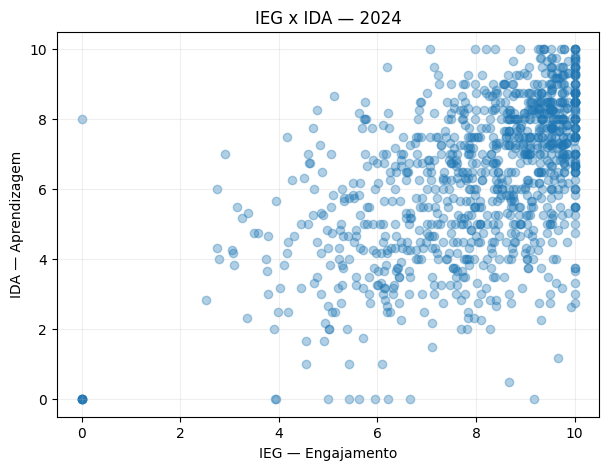

In [14]:
dados_2024 = df[df["ano"] == 2024].dropna(subset=["ieg", "ida"])

plt.figure(figsize=(7, 5))
plt.scatter(dados_2024["ieg"], dados_2024["ida"], alpha=0.35)
plt.title("IEG x IDA — 2024")
plt.xlabel("IEG — Engajamento")
plt.ylabel("IDA — Aprendizagem")
plt.grid(alpha=0.2)
plt.show()

### Insight — engajamento

A associação é positiva e consistente nos três anos:

| Relação | 2022 | 2023 | 2024 |
|---|---:|---:|---:|
| IEG × IDA | **0,564** | **0,461** | **0,538** |
| IEG × IPV | **0,589** | **0,449** | **0,535** |

Alunos mais engajados tendem a apresentar maior desempenho e maior indicador de ponto de virada. A relação é moderada, relevante para acompanhamento, mas não demonstra que engajamento sozinho cause os resultados.

# Pergunta 4 — Autoavaliação (IAA)

> A percepção dos alunos sobre si mesmos é coerente com desempenho e engajamento?

In [15]:
relacoes_iaa = []

for ano, dados in df.groupby("ano"):
    corr = dados[["iaa", "ida", "ieg"]].corr()

    base_gap = dados[["iaa", "ida", "ieg"]].dropna()
    gap_ida = (base_gap["iaa"] - base_gap["ida"]).abs()
    gap_ieg = (base_gap["iaa"] - base_gap["ieg"]).abs()

    relacoes_iaa.append({
        "ano": ano,
        "corr_IAA_IDA": corr.loc["iaa", "ida"],
        "corr_IAA_IEG": corr.loc["iaa", "ieg"],
        "gap_medio_IAA_IDA": gap_ida.mean(),
        "% gap IAA-IDA >= 2": (gap_ida >= 2).mean() * 100,
        "gap_medio_IAA_IEG": gap_ieg.mean(),
    })

relacoes_iaa = pd.DataFrame(relacoes_iaa)
display(relacoes_iaa.round(2))

,ano,corr_IAA_IDA,corr_IAA_IEG,gap_medio_IAA_IDA,% gap IAA-IDA >= 2,gap_medio_IAA_IEG
0,2022,0.21,0.32,2.74,59.07,1.57
1,2023,0.10,0.17,2.99,59.12,2.53
2,2024,0.22,0.23,2.55,54.93,1.46


### Insight — autoavaliação

A autoavaliação apresenta **coerência limitada** com os indicadores objetivos:

- correlação IAA × IDA varia apenas de aproximadamente **0,10 a 0,22**;
- correlação IAA × IEG varia de aproximadamente **0,17 a 0,32**;
- em 2024, cerca de **55%** dos alunos avaliados apresentam diferença absoluta de pelo menos 2 pontos entre IAA e IDA.

Isso sugere que a percepção do aluno acrescenta uma dimensão diferente da aprendizagem medida e não deve ser usada como substituta do desempenho real.

# Pergunta 5 — Aspectos psicossociais (IPS)

> Há padrões psicossociais que antecedem quedas de desempenho acadêmico ou engajamento?

Para testar a ideia de antecedência, usamos o IPS de 2023 e calculamos a variação dos mesmos alunos entre 2023 e 2024.

In [16]:
d23 = df[df["ano"] == 2023].set_index("ra")
d24 = df[df["ano"] == 2024].set_index("ra")

long_23_24 = d23[
    ["ips", "ipp", "ida", "ieg", "ipv", "ian", "inde", "iaa", "defasagem", "em_defasagem"]
].join(
    d24[
        ["ips", "ipp", "ida", "ieg", "ipv", "ian", "inde", "iaa", "defasagem", "em_defasagem"]
    ],
    how="inner",
    lsuffix="_2023",
    rsuffix="_2024"
)

for indicador in ["ida", "ieg", "ipv", "inde"]:
    long_23_24[f"delta_{indicador}"] = (
        long_23_24[f"{indicador}_2024"] - long_23_24[f"{indicador}_2023"]
    )

antecedencia_ips = pd.DataFrame({
    "desfecho": ["Δ IDA 2024-2023", "Δ IEG 2024-2023", "Δ IPV 2024-2023", "Δ INDE 2024-2023"],
    "correlacao_com_IPS_2023": [
        long_23_24[["ips_2023", "delta_ida"]].corr().iloc[0, 1],
        long_23_24[["ips_2023", "delta_ieg"]].corr().iloc[0, 1],
        long_23_24[["ips_2023", "delta_ipv"]].corr().iloc[0, 1],
        long_23_24[["ips_2023", "delta_inde"]].corr().iloc[0, 1],
    ]
})

display(antecedencia_ips.round(3))

,desfecho,correlacao_com_IPS_2023
0,Δ IDA 2024-2023,0.049
1,Δ IEG 2024-2023,0.007
2,Δ IPV 2024-2023,0.053
3,Δ INDE 2024-2023,-0.156


### Insight — IPS como antecedente

Na comparação 2023 → 2024, o IPS de 2023 apresentou correlação de aproximadamente:

- **0,049** com a variação futura do IDA;
- **0,007** com a variação futura do IEG;
- **0,053** com a variação futura do IPV;
- **-0,156** com a variação futura do INDE.

Portanto, **não aparece um padrão linear forte** em que o IPS isoladamente antecipe queda de desempenho ou engajamento.

Isso não significa que aspectos psicossociais sejam irrelevantes. Eles podem atuar de forma não linear ou em combinação com outros indicadores, hipótese que poderá ser testada pelo modelo de Machine Learning.

# Pergunta 6 — Aspectos psicopedagógicos (IPP)

> O IPP confirma ou contradiz a defasagem indicada pelo IAN?

O IPP não está disponível em 2022, então esta análise utiliza 2023 e 2024.

In [17]:
ipp_status = (
    df[df["ano"].isin([2023, 2024])]
    .groupby(["ano", "status_defasagem"])
    .agg(
        alunos=("ra", "size"),
        ipp_medio=("ipp", "mean"),
        ian_medio=("ian", "mean"),
        ida_medio=("ida", "mean"),
        inde_medio=("inde", "mean"),
    )
    .reset_index()
)

display(ipp_status.round(2))

,ano,status_defasagem,alunos,ipp_medio,ian_medio,ida_medio,inde_medio
0,2023,Adequado,420,7.64,10.00,6.95,7.79
1,2023,Adiantado,42,7.99,10.00,6.54,7.56
2,2023,Defasado,552,7.49,4.94,6.48,7.03
3,2024,Adequado,487,7.64,10.00,6.38,7.71
4,2024,Adiantado,135,7.91,10.00,6.95,8.05
5,2024,Defasado,534,7.41,4.99,6.22,7.03


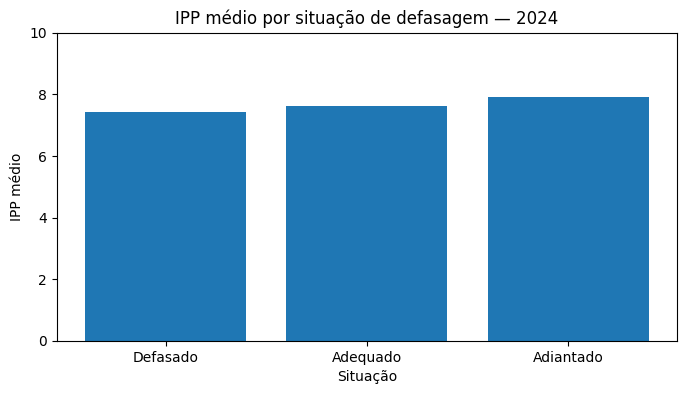

In [18]:
ipp_2024 = (
    ipp_status[ipp_status["ano"] == 2024]
    .sort_values("ipp_medio")
)

plt.figure(figsize=(8, 4))
plt.bar(ipp_2024["status_defasagem"], ipp_2024["ipp_medio"])
plt.title("IPP médio por situação de defasagem — 2024")
plt.xlabel("Situação")
plt.ylabel("IPP médio")
plt.ylim(0, 10)
plt.show()

### Insight — IPP e defasagem

O IPP médio é menor entre alunos defasados:

- **2023:** defasados ≈ **7,49**, adequados ≈ **7,64**, adiantados ≈ **7,99**;
- **2024:** defasados ≈ **7,41**, adequados ≈ **7,64**, adiantados ≈ **7,91**.

A diferença existe, mas é relativamente pequena. A correlação entre IPP e IAN também é baixa (**0,095 em 2023** e **0,154 em 2024**).

Assim, o IPP **não contradiz** a defasagem, mas também **não a reproduz diretamente**. Ele parece capturar uma dimensão complementar do aluno.

# Pergunta 7 — Ponto de virada (IPV)

> Quais comportamentos acadêmicos, emocionais ou de engajamento estão mais associados ao IPV?

In [19]:
variaveis_ipv = ["ida", "ieg", "iaa", "ips", "ipp", "ian"]

drivers_ipv = []

for ano, dados in df.groupby("ano"):
    corr = dados[variaveis_ipv + ["ipv"]].corr()["ipv"].drop("ipv")

    for indicador, valor in corr.items():
        drivers_ipv.append({
            "ano": ano,
            "indicador": indicador.upper(),
            "correlacao_IPV": valor
        })

drivers_ipv = pd.DataFrame(drivers_ipv)

display(
    drivers_ipv
    .pivot(index="indicador", columns="ano", values="correlacao_IPV")
    .round(3)
)

ano,2022,2023,2024
indicador,,,
IAA,0.256,0.138,0.148
IAN,0.111,0.147,0.185
IDA,0.617,0.544,0.514
IEG,0.589,0.449,0.535
IPP,NaN,0.516,0.750
IPS,0.208,0.078,0.105


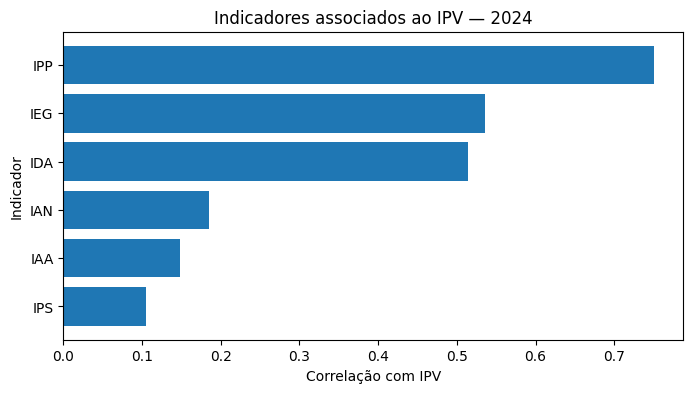

In [20]:
drivers_2024 = (
    drivers_ipv[drivers_ipv["ano"] == 2024]
    .dropna()
    .sort_values("correlacao_IPV")
)

plt.figure(figsize=(8, 4))
plt.barh(drivers_2024["indicador"], drivers_2024["correlacao_IPV"])
plt.title("Indicadores associados ao IPV — 2024")
plt.xlabel("Correlação com IPV")
plt.ylabel("Indicador")
plt.show()

### Insight — fatores associados ao IPV

Os padrões mais consistentes são:

- **2022:** IDA (**0,617**) e IEG (**0,589**);
- **2023:** IDA (**0,544**), IPP (**0,516**) e IEG (**0,449**);
- **2024:** IPP (**0,750**), IEG (**0,535**) e IDA (**0,514**).

Em 2024, o indicador psicopedagógico ganha forte associação com o ponto de virada. Engajamento e aprendizagem permanecem relevantes em todos os períodos.

# Pergunta 8 — Multidimensionalidade dos indicadores

> Quais combinações de IDA + IEG + IPS + IPP estão associadas aos maiores níveis de INDE?

Para tornar a combinação interpretável, cada indicador de 2024 é classificado como **Alto** ou **Baixo** em relação à mediana do próprio ano. Em seguida, calculamos o INDE médio de cada combinação.

Essa abordagem é descritiva e não representa causalidade.

In [21]:
base_combo = df[df["ano"] == 2024].dropna(
    subset=["ida", "ieg", "ips", "ipp", "inde"]
).copy()

combo_cols = ["ida", "ieg", "ips", "ipp"]
medianas = base_combo[combo_cols].median()

for coluna in combo_cols:
    base_combo[f"{coluna}_nivel"] = np.where(
        base_combo[coluna] >= medianas[coluna],
        "Alto",
        "Baixo"
    )

base_combo["combinacao"] = (
    "IDA " + base_combo["ida_nivel"] +
    " | IEG " + base_combo["ieg_nivel"] +
    " | IPS " + base_combo["ips_nivel"] +
    " | IPP " + base_combo["ipp_nivel"]
)

combinacoes = (
    base_combo.groupby("combinacao")
    .agg(
        alunos=("ra", "size"),
        inde_medio=("inde", "mean")
    )
    .query("alunos >= 15")
    .sort_values("inde_medio", ascending=False)
)

display(combinacoes.round(2))

,alunos,inde_medio
combinacao,,
IDA Alto | IEG Alto | IPS Alto | IPP Alto,193,8.40
IDA Alto | IEG Alto | IPS Baixo | IPP Alto,128,8.32
IDA Alto | IEG Alto | IPS Alto | IPP Baixo,26,7.89
IDA Alto | IEG Baixo | IPS Alto | IPP Alto,76,7.82
IDA Baixo | IEG Alto | IPS Alto | IPP Alto,73,7.72
IDA Alto | IEG Alto | IPS Baixo | IPP Baixo,22,7.65
IDA Baixo | IEG Alto | IPS Baixo | IPP Alto,36,7.45
IDA Alto | IEG Baixo | IPS Baixo | IPP Alto,31,7.44
IDA Alto | IEG Baixo | IPS Alto | IPP Baixo,29,7.33


### Insight — multidimensionalidade

A combinação **IDA alto + IEG alto + IPS alto + IPP alto** apresentou INDE médio de aproximadamente **8,38** em 2024.

Na outra ponta, a combinação em que os quatro indicadores ficaram abaixo da mediana apresentou INDE médio de aproximadamente **5,93**.

Também chama atenção que configurações com **IDA e IEG altos** permanecem entre as maiores médias de INDE mesmo quando IPS ou IPP ficam abaixo da mediana. Isso reforça a relevância conjunta de aprendizagem e engajamento, sem eliminar a contribuição das dimensões psicossocial e psicopedagógica.

# Pergunta 9 — Preparação para previsão de risco

> Quais padrões podem ajudar a identificar alunos antes de uma nova defasagem?

O modelo será construído no notebook `04_modelo_ml.ipynb`. Aqui verificamos apenas se existe sinal preditivo no recorte temporal.

A análise considera alunos que **não estavam defasados em 2023** e verifica quem entrou em defasagem em 2024.

In [22]:
elegiveis = df_modelo[
    df_modelo["elegivel_nova_defasagem_2024"] == 1
].copy()

total_elegiveis = len(elegiveis)
novos_casos = int(elegiveis["entrou_em_defasagem_2024"].sum())
taxa_novos = elegiveis["entrou_em_defasagem_2024"].mean() * 100

print(f"Alunos elegíveis: {total_elegiveis}")
print(f"Entraram em defasagem em 2024: {novos_casos}")
print(f"Taxa de novos casos: {taxa_novos:.1f}%")

Alunos elegíveis: 370
Entraram em defasagem em 2024: 84
Taxa de novos casos: 22.7%


In [23]:
features_2023 = [
    "ida_2023", "ieg_2023", "iaa_2023",
    "ips_2023", "ipp_2023", "ipv_2023", "inde_2023"
]

comparacao_risco = (
    elegiveis.groupby("entrou_em_defasagem_2024")[features_2023]
    .mean()
    .T
)

comparacao_risco.columns = ["Não entrou em defasagem", "Entrou em defasagem"]
comparacao_risco["Diferença"] = (
    comparacao_risco["Entrou em defasagem"]
    - comparacao_risco["Não entrou em defasagem"]
)

display(comparacao_risco.round(2))

,Não entrou em defasagem,Entrou em defasagem,Diferença
ida_2023,7.07,6.79,-0.28
ieg_2023,9.16,8.86,-0.30
iaa_2023,7.14,7.26,0.12
ips_2023,4.62,5.75,1.12
ipp_2023,8.01,7.09,-0.92
ipv_2023,8.38,7.94,-0.44
inde_2023,7.90,7.72,-0.18


### Insight — sinal para o futuro modelo

Dos **370 alunos elegíveis**, **84 entraram em defasagem em 2024**, uma incidência de **22,7%**.

Em 2023, os alunos que posteriormente entraram em defasagem apresentavam, em média:

- IPP: **7,09** vs **8,01**;
- IPV: **7,94** vs **8,38**;
- IEG: **8,86** vs **9,16**;
- IDA: **6,79** vs **7,07**.

O IPS apresentou comportamento inverso ao que uma interpretação intuitiva poderia sugerir (**5,75** no grupo que entrou em defasagem vs **4,62** no grupo que não entrou). Isso reforça que o modelo deve aprender padrões a partir dos dados, sem impor a hipótese de que valores maiores ou menores são sempre melhores.

O `IAN_2023` não diferencia esse subconjunto porque os alunos elegíveis já eram não defasados em 2023 e, portanto, apresentam IAN compatível com adequação. Essa variável deve ser avaliada com cuidado no modelo.

# Pergunta 10 — Efetividade do programa

> Os indicadores mostram melhora consistente ao longo do ciclo?

A resposta precisa considerar tanto indicadores agregados quanto o acompanhamento dos mesmos alunos.

In [24]:
pedras = (
    df.dropna(subset=["pedra"])
    .groupby(["ano", "pedra"])
    .size()
    .rename("alunos")
    .reset_index()
)

pedras["percentual"] = (
    pedras["alunos"]
    / pedras.groupby("ano")["alunos"].transform("sum")
    * 100
)

display(
    pedras.pivot(index="ano", columns="pedra", values="percentual")
    .round(2)
)

pedra,Ametista,Quartzo,Topázio,Ágata
ano,,,,
2022,40.47,15.35,15.12,29.07
2023,40.92,7.73,24.92,26.42
2024,37.10,10.63,30.93,21.35


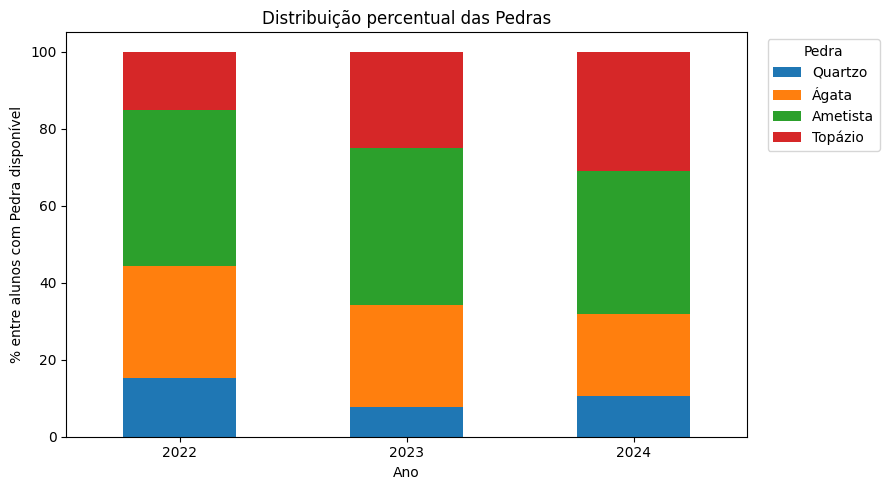

In [25]:
ordem_pedras = ["Quartzo", "Ágata", "Ametista", "Topázio"]

pedras_pivot = (
    pedras.pivot(index="ano", columns="pedra", values="percentual")
    .reindex(columns=ordem_pedras)
    .fillna(0)
)

pedras_pivot.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Distribuição percentual das Pedras")
plt.xlabel("Ano")
plt.ylabel("% entre alunos com Pedra disponível")
plt.xticks(rotation=0)
plt.legend(title="Pedra", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Insight — efetividade

Existem sinais agregados positivos:

- defasagem: **69,9% → 54,4% → 46,2%**;
- INDE médio: **7,04 → 7,34 → 7,40**;
- Topázio entre alunos com classificação disponível: **15,1% → 24,9% → 30,9%**;
- casos de maior defasagem (`IAN = 2.5`): **28 → 14 → 3**.

Por outro lado, a melhora **não é uniforme em todos os indicadores**:

- IDA: **6,09 → 6,66 → 6,35**;
- IEG: **7,89 → 8,70 → 7,37**;
- IPV: **7,25 → 8,03 → 7,35**.

Entre os mesmos alunos de 2023 e 2024, IDA, IEG e IPV também apresentam queda média.

Assim, os dados mostram **evidências positivas de adequação ao nível e evolução do INDE agregado**, mas não sustentam a afirmação de que houve melhora consistente em todas as dimensões. Além disso, estes dados observacionais não permitem atribuir causalmente as mudanças ao programa sem um desenho de avaliação de impacto.

# Pergunta 11 — Insights adicionais

## Transição da defasagem entre 2023 e 2024

Além da taxa agregada, é útil entender o fluxo dos alunos: quem saiu da defasagem e quem entrou nela.

In [26]:
transicao = pd.crosstab(
    long_23_24["em_defasagem_2023"],
    long_23_24["em_defasagem_2024"],
    rownames=["Defasagem em 2023"],
    colnames=["Defasagem em 2024"]
)

display(transicao)

recuperados = transicao.loc[1.0, 0.0]
defasados_2023 = transicao.loc[1.0].sum()
novos = transicao.loc[0.0, 1.0]
adequados_2023 = transicao.loc[0.0].sum()

print(f"Recuperação entre defasados de 2023: {recuperados / defasados_2023 * 100:.1f}%")
print(f"Entrada em defasagem entre não defasados de 2023: {novos / adequados_2023 * 100:.1f}%")

Defasagem em 2024,0.0,1.0
Defasagem em 2023,,
0.0,286,84
1.0,171,224


Recuperação entre defasados de 2023: 43.3%
Entrada em defasagem entre não defasados de 2023: 22.7%


### Insight adicional — dinâmica de recuperação e risco

Entre os **765 alunos presentes em 2023 e 2024**:

- **171 de 395** alunos que estavam defasados em 2023 deixaram a defasagem em 2024 — recuperação de aproximadamente **43,3%**;
- **84 de 370** alunos que não estavam defasados em 2023 entraram em defasagem em 2024 — incidência de aproximadamente **22,7%**.

Esse é um insight gerencial importante: mesmo com queda da taxa geral de defasagem, existe um grupo relevante de alunos que **entra em risco de um ano para o outro**. É exatamente esse grupo que o modelo preditivo deverá tentar identificar antecipadamente.

# Conclusões gerenciais

A análise exploratória permite responder às principais dores do Datathon:

1. **Adequação ao nível:** houve redução forte da defasagem, especialmente dos casos mais profundos.
2. **Desempenho acadêmico:** o IDA melhorou em 2023, mas recuou em 2024; não existe tendência contínua de alta.
3. **Engajamento:** IEG apresenta associação moderada e consistente com IDA e IPV.
4. **Autoavaliação:** IAA possui alinhamento apenas fraco com desempenho e engajamento, trazendo uma perspectiva complementar.
5. **Psicossocial:** IPS isolado não mostrou forte capacidade linear de anteceder queda de IDA/IEG.
6. **Psicopedagógico:** IPP é um pouco menor entre alunos defasados e se torna fortemente associado ao IPV em 2024.
7. **Ponto de virada:** IDA, IEG e IPP são os indicadores mais associados ao IPV.
8. **Multidimensionalidade:** alunos com IDA, IEG, IPS e IPP simultaneamente altos apresentam os maiores níveis médios de INDE.
9. **Risco futuro:** existem 370 alunos adequados em 2023 com acompanhamento em 2024; 84 deles entram em defasagem, formando um alvo temporal viável para ML.
10. **Efetividade:** há melhora clara em defasagem, IAN, INDE agregado e participação em Topázio, mas o avanço não é uniforme em todas as dimensões.
11. **Insight operacional:** 43,3% dos defasados acompanhados de 2023 para 2024 se recuperaram, enquanto 22,7% dos inicialmente não defasados entraram em defasagem.

## Próximo passo

O notebook `04_modelo_ml.ipynb` deverá:

- definir formalmente a variável-alvo;
- evitar vazamento de dados;
- realizar feature engineering;
- separar treino e teste respeitando a lógica temporal;
- comparar algoritmos;
- avaliar especialmente **recall, precision, F1, ROC-AUC e matriz de confusão**;
- calibrar a probabilidade de risco;
- explicar as previsões com importância de variáveis/SHAP;
- exportar o modelo para utilização no Streamlit.